# Growth estimation

**Reza Sameni**  
Emory University

Lagged ratios, log-linear regression, and nonlinear exponential fitting.

## Topics

- Recover growth from a known exponential.
- Explain endpoint behavior and one-step forecasts.
- Avoid confusing per-sample growth with a biological reproduction number.

**Run:** install the package with `python -m pip install -e ".[notebooks,dev]"`, then run all cells in order. All numerical functions are imported from `src/epidemic_modeling`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, HTML
import epidemic_modeling as em
from epidemic_modeling.plotting import (
    configure_plots,
    repository_root,
    plot_compartments,
    plot_growth,
)

root = repository_root()
configure_plots()
print(f"epidemic_modeling {em.__version__} · local data")


epidemic_modeling 2.0.0 · local data


## Controlled ground truth

For $c_k=Ae^{\lambda k}$, rolling log regression should recover $\lambda$ after a full window. The legacy functions label their output `rt`; this is an exponential growth factor under their sampling convention, not a generation-interval-calibrated epidemiological $R_t$.

`exp_fit = amplitude * rt` is a **one-step forecast**, not a reconstruction of the current observed point. Centered estimates use future data and are useful for retrospective visualization only.

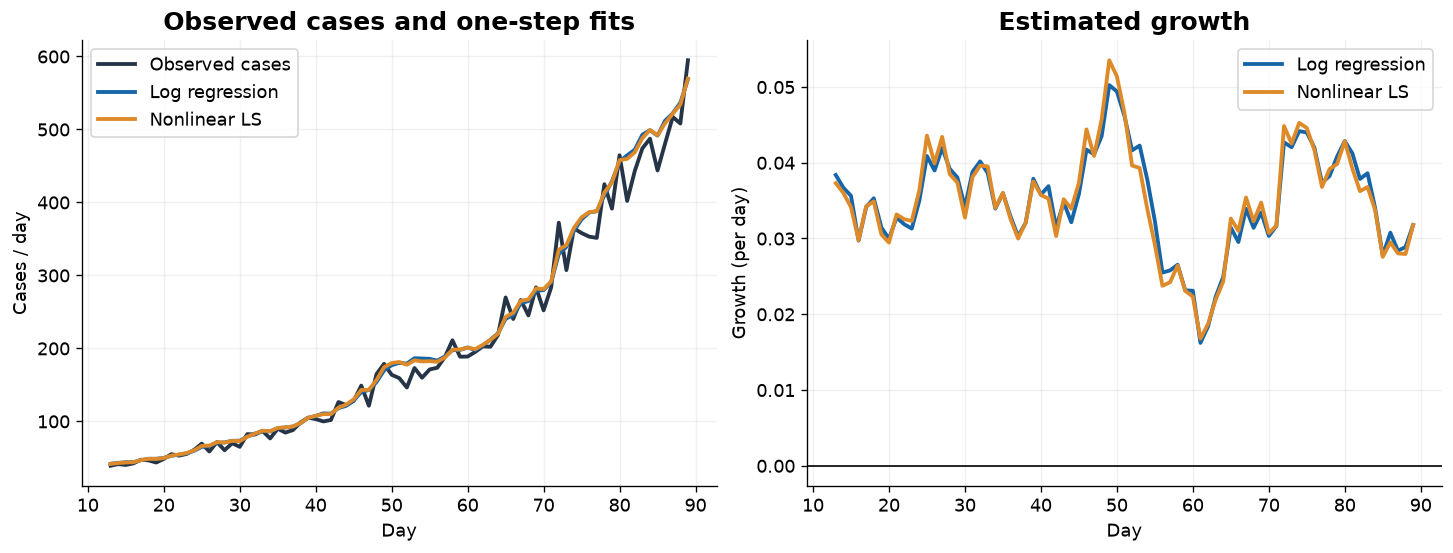

In [2]:
day = np.arange(90)
true_growth = 0.035
exact = 25 * np.exp(true_growth * day)
rng = np.random.default_rng(2026)
cases = exact * np.exp(rng.normal(0, 0.08, len(day)))
log_fit = em.rt_exp_fit_log_lin_reg(cases, 14, 1.0)
nonlinear_fit = em.rt_exp_fit_nonlin_ls(cases, 14, 1.0)
plot_growth(
    day[13:],
    cases[13:],
    {
        "Log regression": tuple(a[13:] for a in log_fit),
        "Nonlinear LS": tuple(a[13:] for a in nonlinear_fit),
    },
)
plt.show()
known = em.rt_exp_fit_log_lin_reg(exact, 14, 1.0)
assert np.allclose(known[2][13:], true_growth)


## Lagged ratios and causal smoothing

The ratio method compares cases separated by `generation_period` samples, then smooths with a zero-padded moving average. Early estimates are intentionally zero-growth. Case zeros make ratios undefined; preprocessing decisions should be documented rather than hidden.

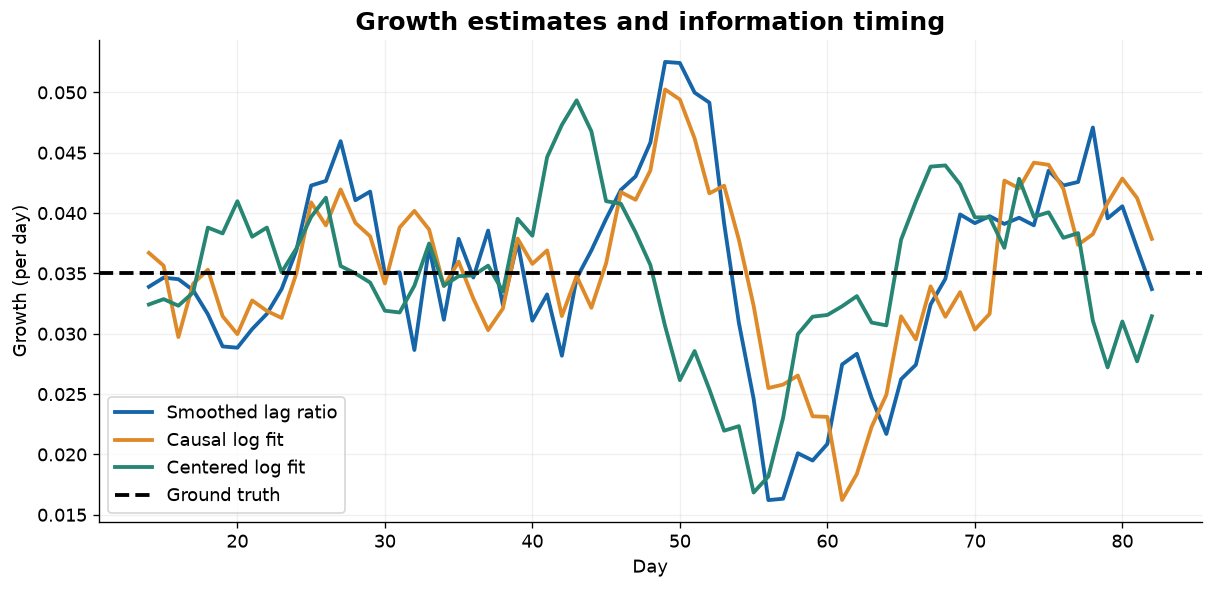

In [3]:
rt, growth, rt_smooth, growth_smooth = em.rt_exp_fit_gen_ratios(cases, 7, 5, 1.0)
centered = em.rt_exp_fit_log_lin_reg(cases, 14, 1.0, causal=False)
fig, ax = plt.subplots()
ax.plot(day[14:-7], growth_smooth[14:-7], label="Smoothed lag ratio")
ax.plot(day[14:-7], log_fit[2][14:-7], label="Causal log fit")
ax.plot(day[14:-7], centered[2][14:-7], label="Centered log fit")
ax.axhline(true_growth, color="black", linestyle="--", label="Ground truth")
ax.set(
    title="Growth estimates and information timing",
    xlabel="Day",
    ylabel="Growth (per day)",
)
ax.legend()
plt.show()


## Further experiments

- Change the window from 14 to 7 and explain the variance/smoothness tradeoff.
- Add a reporting zero; inspect how each estimator handles it.
- Inspect `docs/api.md` before using a `time_unit` different from one: nonlinear fitting preserves the historical scaling, which differs from log-linear fitting.

**Paired MATLAB example:** `demo_growth_estimation`.

## References and next steps

1. Reza Sameni (2020). *Mathematical Modeling of Epidemic Diseases; A Case Study of the COVID-19 Coronavirus*. [arXiv:2003.11371](https://arxiv.org/abs/2003.11371).
2. Reza Sameni (2022). *Model-Based Prediction and Optimal Control of Pandemics by Non-Pharmaceutical Interventions*. IEEE JSTSP, **16**(2), 307–317. [DOI:10.1109/JSTSP.2021.3129118](https://doi.org/10.1109/JSTSP.2021.3129118).

Equations and existing research images originate from the cited work and the [original repository](https://github.com/alphanumericslab/EpidemicModeling). Consult `docs/api.md` for array shapes and `docs/migration.md` for deliberate fixes.